Penguins Dashboard

Dataset head
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
Shape
(344, 7)
Info
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null   

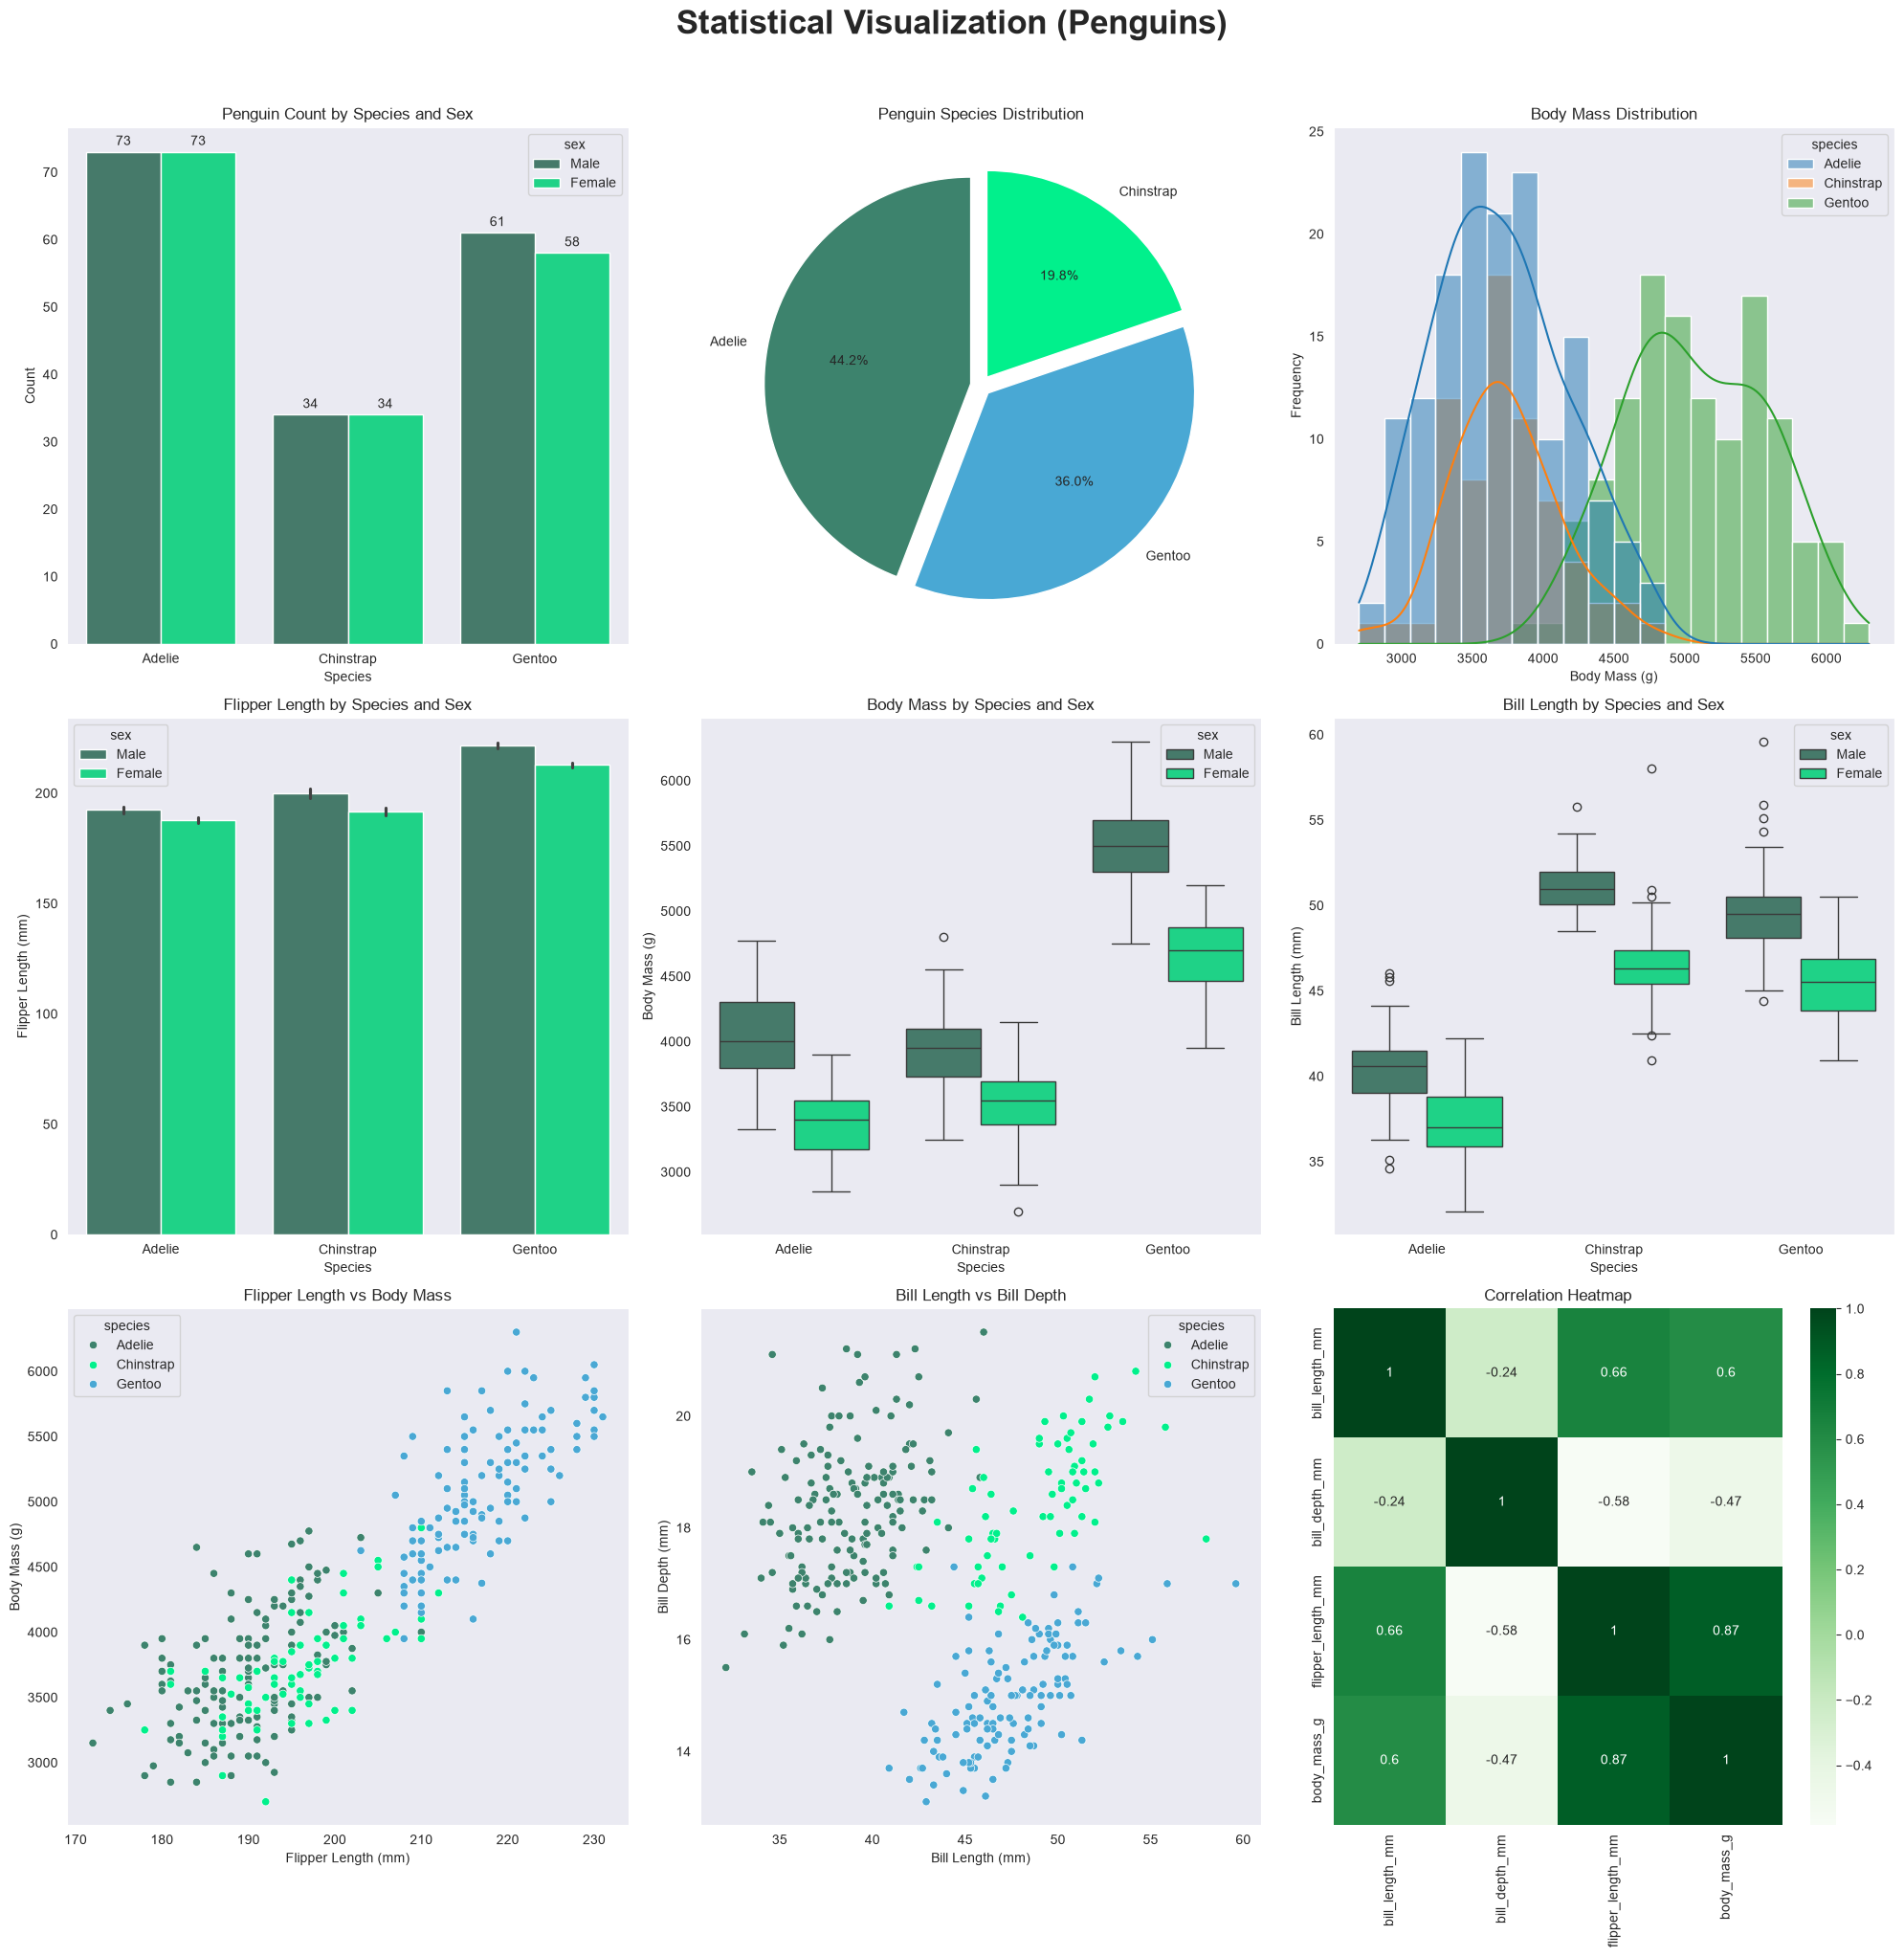

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins")

# Head
print("Dataset head")
print(penguins.head())

# Shape
print("Shape")
print(penguins.shape)

# Info
print("Info")
penguins.info()

# Description
print("Description")
print(penguins.describe())

# Null values
print("Null Values")
print(penguins.isnull().sum())

# Duplicates
print("Duplicate Values")
print(penguins.duplicated().sum())

# Unique Values
print("Unique Values")
print(penguins.nunique())


# Set seaborn style
sns.set_style("dark")

# Color schemes
sex_colors = {
    "Male": "#3D836D",
    "Female": "#01F08C"
}

species_colors = {
    "Adelie": "#3D836D",
    "Chinstrap": "#01F08C",
    "Gentoo": "#49A8D4"
}


fig, axes = plt.subplots(3, 3, figsize=(20, 20))

fig.suptitle(
    "Statistical Visualization (Penguins)",
    fontsize=25,
    fontweight="bold", 
    y = 1.02
)

#SPECIES COUNT BY SEX
ax = sns.countplot(
    data=penguins,
    x="species",
    hue="sex",
    palette=sex_colors,
    ax=axes[0, 0]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

axes[0, 0].set_title("Penguin Count by Species and Sex")
axes[0, 0].set_xlabel("Species")
axes[0, 0].set_ylabel("Count")


#SPECIES DISTRIBUTION
species_count = penguins["species"].value_counts()

explode = (0.05, 0.05, 0.05)

axes[0, 1].pie(
    species_count,
    labels=species_count.index,
    autopct="%1.1f%%",
    explode=explode,
    colors=[species_colors[s] for s in species_count.index],
    startangle=90
)

axes[0, 1].set_title("Penguin Species Distribution")


#BODY MASS DISTRIBUTION
sns.histplot(
    data=penguins,
    x="body_mass_g",
    kde=True,
    bins=20,
    hue= "species",
    ax=axes[0, 2]
)

axes[0, 2].set_title("Body Mass Distribution")
axes[0, 2].set_xlabel("Body Mass (g)")
axes[0, 2].set_ylabel("Frequency")


#FLIPPER LENGTH BY SPECIES AND SEX
sns.barplot(
    data=penguins,
    x="species",
    y="flipper_length_mm",
    hue="sex",
    palette=sex_colors,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Flipper Length by Species and Sex")
axes[1, 0].set_xlabel("Species")
axes[1, 0].set_ylabel("Flipper Length (mm)")


#BODY MASS BY SPECIES AND SEX
sns.boxplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    hue="sex",
    palette=sex_colors,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Body Mass by Species and Sex")
axes[1, 1].set_xlabel("Species")
axes[1, 1].set_ylabel("Body Mass (g)")


#BILL LENGTH BY SPECIES AND SEX
sns.boxplot(
    data=penguins,
    x="species",
    y="bill_length_mm",
    hue="sex",
    palette=sex_colors,
    ax=axes[1, 2]
)

axes[1, 2].set_title("Bill Length by Species and Sex")
axes[1, 2].set_xlabel("Species")
axes[1, 2].set_ylabel("Bill Length (mm)")


#FLIPPER LENGTH VS BODY MASS
sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    palette=species_colors,
    ax=axes[2, 0]
)

axes[2, 0].set_title("Flipper Length vs Body Mass")
axes[2, 0].set_xlabel("Flipper Length (mm)")
axes[2, 0].set_ylabel("Body Mass (g)")


#BILL LENGTH VS BILL DEPTH
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette=species_colors,
    ax=axes[2, 1]
)

axes[2, 1].set_title("Bill Length vs Bill Depth")
axes[2, 1].set_xlabel("Bill Length (mm)")
axes[2, 1].set_ylabel("Bill Depth (mm)")


#CORRELATION HEATMAP
numeric_data = penguins.select_dtypes(include="number")

correlation = numeric_data.corr()

sns.heatmap(
    data=correlation,
    annot=True,
    cmap="Greens",
    ax=axes[2, 2]
)

axes[2, 2].set_title("Correlation Heatmap")


plt.tight_layout()
plt.show()